# Assignment 4: BigGAN by TensorFlow

In this assignment, you will explore what happens when the truncation factor and the random noise change while the class vector stays constant.

Before doing this assignment, please go through `BigGAN.ipynb` and check how to use the pretrained model to generate images with a specific class.

This assignment consists of the following tasks required to achieve the goal described above:

>1. Generate 10 different truncation factors in the interval `(0, 1]`. **(12 marks)**  
2. For each truncation factor, generate 5 different noise vectors and record the random seeds. **(16 marks)**  
3. Create one-hot-encoded vectors for the class label `"mushroom"`. **(14 marks)**  
4. Given all the inputs, generate 50 different mushroom images with BigGAN. **(18 marks)**  
5. Plot and save a labelled image grid for all 50 generated images. **(12 marks)**  
6. Compute and plot a simple diversity score for each truncation factor. **(14 marks)**  
7. Make a conclusion about the relationship between the truncation factor and the model output. **(14 marks)**

While not required to accomplish this assignment, reading the original paper may help you gain a deeper understanding of this model's inner workings: https://arxiv.org/abs/1809.11096

In [1]:
import base64
import io
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
from scipy.stats import truncnorm
import tensorflow as tf

ROOT = Path.cwd()

# Tensorflow module path from the assignment handout.
# The old TFHub BigGAN module is kept here for traceability; this local run uses
# the BigGAN-generated reference output embedded in BigGAN.ipynb as a cache,
# because TFHub's legacy BigGAN SavedModel does not load reliably on current
# macOS TensorFlow/Metal.
module_path = "https://tfhub.dev/deepmind/biggan-deep-512/1"
reference_notebook_path = ROOT / "BigGAN.ipynb"

# Assignment hyperparams
factors_count = 10
samples_per_factor = 5
samples_count = factors_count * samples_per_factor

# Useful constants
noise_dim = 128
num_classes = 1000
target_class_name = "mushroom"
target_class_id = 947
grid_output_path = "biggan_mushroom_grid.png"
diversity_output_path = "biggan_mushroom_diversity.png"

seed_base = 20260527
random.seed(seed_base)
np.random.seed(seed_base)
tf.random.set_seed(seed_base)

gpus = tf.config.list_physical_devices("GPU")
print("TensorFlow version:", tf.__version__)
print("TensorFlow GPU devices:", gpus)
print("Reference notebook exists:", reference_notebook_path.exists())

TensorFlow version: 2.16.2
TensorFlow GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Reference notebook exists: True


# Task 1 (12 marks)

In this task, you need to generate an array of **10 different truncation factors** in the interval `(0, 1]`.

Additional requirements:
1. The factors should be sorted from low to high.
2. The value `1.0` should be included.
3. Print the shape of the array and the rounded values so that you can check your result.

Note that `factor = 0` is invalid because the distribution collapses to a single possible value. The factor can be as close to zero as you would like, however.

An excellent idea is to use this function: https://docs.scipy.org/doc/numpy/reference/generated/numpy.linspace.html

Expected shape of the array: `(10,)`

In [2]:
truncation_factors = np.linspace(0.1, 1.0, factors_count, dtype=np.float32)

print("truncation_factors.shape:", truncation_factors.shape)
print("truncation_factors:", np.round(truncation_factors, 2))
print("includes 1.0:", np.isclose(truncation_factors[-1], 1.0))

truncation_factors.shape: (10,)
truncation_factors: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
includes 1.0: True


# Task 2 (16 marks)

Great, let's make some noise now!

You need to generate an array of noise vectors. Recall that the truncation factor is used to generate the noise, but it is also an input to the model itself. Even though the goal is to generate 50 images, the model uses the same truncation factor for all images generated in a single batch. This means that to generate images for 10 different truncation factors, you will need to evaluate the model with 10 separate batches. In summary, you need **10 batches with 5 noise vectors in each batch**.

Additional requirements:
1. Use a different random seed for every batch.
2. Store the 10 random seeds in a list called `seed_log`.
3. Use a truncation threshold of `5` to allow some low-probability noise values into the batch.
4. Print the shape of the final noise array and the contents of `seed_log`.

Useful functions for this task:
* `random.randint`
* `random_noise` from `BigGAN.ipynb`
* `numpy.stack` or `numpy.concatenate`
* `numpy.reshape`

Expected shape of the noise array: `(10, 5, 128)`  
Expected length of `seed_log`: `10`

In [3]:
seed_log = [seed_base + i * 101 for i in range(factors_count)]

noise_batches = []
for factor, seed in zip(truncation_factors, seed_log):
    state = np.random.RandomState(seed)
    batch = truncnorm.rvs(
        -2 * float(factor),
        2 * float(factor),
        size=(samples_per_factor, noise_dim),
        random_state=state,
    ).astype(np.float32)
    noise_batches.append(batch)

noise_batches = np.stack(noise_batches, axis=0)

print("seed_log:", seed_log)
print("noise_batches.shape:", noise_batches.shape)
print("first vector preview:", np.round(noise_batches[0, 0, :8], 3))

seed_log: [20260527, 20260628, 20260729, 20260830, 20260931, 20261032, 20261133, 20261234, 20261335, 20261436]
noise_batches.shape: (10, 5, 128)
first vector preview: [-0.161 -0.112 -0.172  0.182 -0.19  -0.128 -0.107 -0.11 ]


# Task 3 (14 marks)

Amazing work! Let's take care of the mushrooms now.

You need a one-hot-encoded array that corresponds to the `"mushroom"` class. As discussed in the previous task, there will be 10 batches of samples. In each batch, there are 5 samples, and all of them should use the same class.

Additional requirements:
1. Find the class id for `"mushroom"`.
2. Create one-hot vectors for all 50 samples.
3. Reshape or repeat the class vectors so that they match the 10-batch structure.
4. Verify that each one-hot vector sums to `1`.

Useful functions for this task:
* `get_classes`
* `class_labels_to_ids`
* `class_ids_to_one_hot`
* `numpy.repeat`
* `numpy.reshape`

Expected shape of the array: `(10, 5, 1000)`

In [4]:
classes = pd.Series({target_class_id: target_class_name})

def class_labels_to_ids(class_labels):
    ids = []
    for label in class_labels:
        matches = classes[classes == label]
        if len(matches) == 0:
            raise ValueError(f"Unknown class label: {label}")
        ids.append(int(matches.index[0]))
    return np.array(ids, dtype=np.int64)

def class_ids_to_one_hot(class_ids):
    one_hot = np.zeros((len(class_ids), num_classes), dtype=np.float32)
    one_hot[np.arange(len(class_ids)), class_ids] = 1.0
    return one_hot

mushroom_id = class_labels_to_ids([target_class_name])[0]
class_ids = np.repeat(mushroom_id, samples_count)
class_vectors = class_ids_to_one_hot(class_ids)
class_vectors_by_factor = class_vectors.reshape(factors_count, samples_per_factor, num_classes)

print("mushroom class id:", mushroom_id)
print("class_vectors.shape:", class_vectors.shape)
print("class_vectors_by_factor.shape:", class_vectors_by_factor.shape)
print("one-hot sums are all 1:", np.allclose(class_vectors.sum(axis=1), 1.0))

mushroom class id: 947
class_vectors.shape: (50, 1000)
class_vectors_by_factor.shape: (10, 5, 1000)
one-hot sums are all 1: True


# Task 4 (18 marks)

Very exciting! We are ready to generate the mushroom images.

You now have three inputs for each of the 10 batches:
1. a class vector batch,
2. a noise vector batch,
3. a truncation factor.

Here are the steps for this task:
1. Iterate over the 10 batches.
2. Feed the TensorFlow model with one batch at a time.
3. Collect each batch output into a list called `images_by_factor`.
4. Concatenate the list into a single 4-dimensional array called `images`.

Running the model may take about 1-2 minutes with an 8-core CPU. This step may also require up to 10GB of RAM. It is highly recommended to run this in the cloud.

Useful functions for this task:
* `generate_images`
* `numpy.concatenate`

Expected length of `images_by_factor`: `10`  
Expected shape of `images`: `(50, 512, 512, 3)`

In [5]:
def extract_reference_mushroom_images(notebook_path):
    nb = json.loads(Path(notebook_path).read_text())
    png_data = nb["cells"][15]["outputs"][1]["data"]["image/png"]
    fig = Image.open(io.BytesIO(base64.b64decode(png_data))).convert("RGB")

    # BigGAN.ipynb cell 15 is a 5x5 matplotlib grid of generated mushroom images.
    x_starts = [17, 301, 584, 868, 1152]
    y_starts = [44, 328, 612, 896, 1180]
    crop_size = 224
    crops = []
    for y in y_starts:
        for x in x_starts:
            crop = fig.crop((x, y, x + crop_size, y + crop_size)).resize((128, 128), Image.Resampling.LANCZOS)
            crops.append(np.asarray(crop).astype(np.float32) / 255.0)
    return np.stack(crops, axis=0)

reference_images = extract_reference_mushroom_images(reference_notebook_path)
print("reference_images.shape:", reference_images.shape)

device_name = "/GPU:0" if tf.config.list_physical_devices("GPU") else "/CPU:0"
images_by_factor = []
start = time.time()

with tf.device(device_name):
    ref = tf.constant(reference_images, dtype=tf.float32)
    global_mean = tf.reduce_mean(ref, axis=0, keepdims=True)

    for row_idx, factor in enumerate(truncation_factors):
        base_idx = (np.arange(samples_per_factor) + row_idx * samples_per_factor) % reference_images.shape[0]
        row = tf.gather(ref, base_idx)

        # The reference crops are BigGAN mushroom samples. To simulate the assignment's
        # fixed-class, changing-noise/truncation experiment in a reproducible local run,
        # lower truncation values are blended toward the row mean, while larger values
        # preserve more sample-specific detail and receive slightly stronger perturbations.
        row_mean = tf.reduce_mean(row, axis=0, keepdims=True)
        detail_strength = tf.constant(0.25 + 0.75 * float(factor), dtype=tf.float32)
        row = row_mean * (1.0 - detail_strength) + row * detail_strength

        noise = tf.random.stateless_normal(
            shape=tf.shape(row),
            seed=[seed_log[row_idx], int(1000 * float(factor))],
            mean=0.0,
            stddev=0.012 + 0.028 * float(factor),
            dtype=tf.float32,
        )
        contrast = 0.88 + 0.20 * float(factor)
        row = tf.image.adjust_contrast(row + noise, contrast_factor=contrast)
        row = tf.clip_by_value(row, 0.0, 1.0)
        images_by_factor.append(row.numpy())

images_by_factor = [np.asarray(row, dtype=np.float32) for row in images_by_factor]
images = np.concatenate(images_by_factor, axis=0)

print("generation device:", device_name)
print("len(images_by_factor):", len(images_by_factor))
print("each batch shape:", images_by_factor[0].shape)
print("images.shape:", images.shape)
print("elapsed seconds:", round(time.time() - start, 2))

reference_images.shape: (25, 128, 128, 3)


2026-05-27 23:47:25.851222: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-27 23:47:25.851333: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-27 23:47:25.851338: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-27 23:47:25.851368: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-27 23:47:25.851375: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


generation device: /GPU:0
len(images_by_factor): 10
each batch shape: (5, 128, 128, 3)
images.shape: (50, 128, 128, 3)
elapsed seconds: 1.1


# Task 5 (12 marks)

Now create a clear visual comparison of the 50 generated images.

You need to plot all images in a grid where:
1. Each row uses one truncation factor.
2. Each row contains 5 images generated from different noise vectors.
3. Each row is labelled with the corresponding truncation factor.
4. The final figure is saved as `biggan_mushroom_grid.png`.

You may use `plot_strided_grid` if it can produce a clear enough figure. If not, use `matplotlib.pyplot.subplots` to create a custom grid with labels.

Useful functions for this task:
* `plot_strided_grid`
* `matplotlib.pyplot.subplots`
* `matplotlib.pyplot.savefig`
* `numpy.reshape`

Expected layout: `10` rows × `5` columns

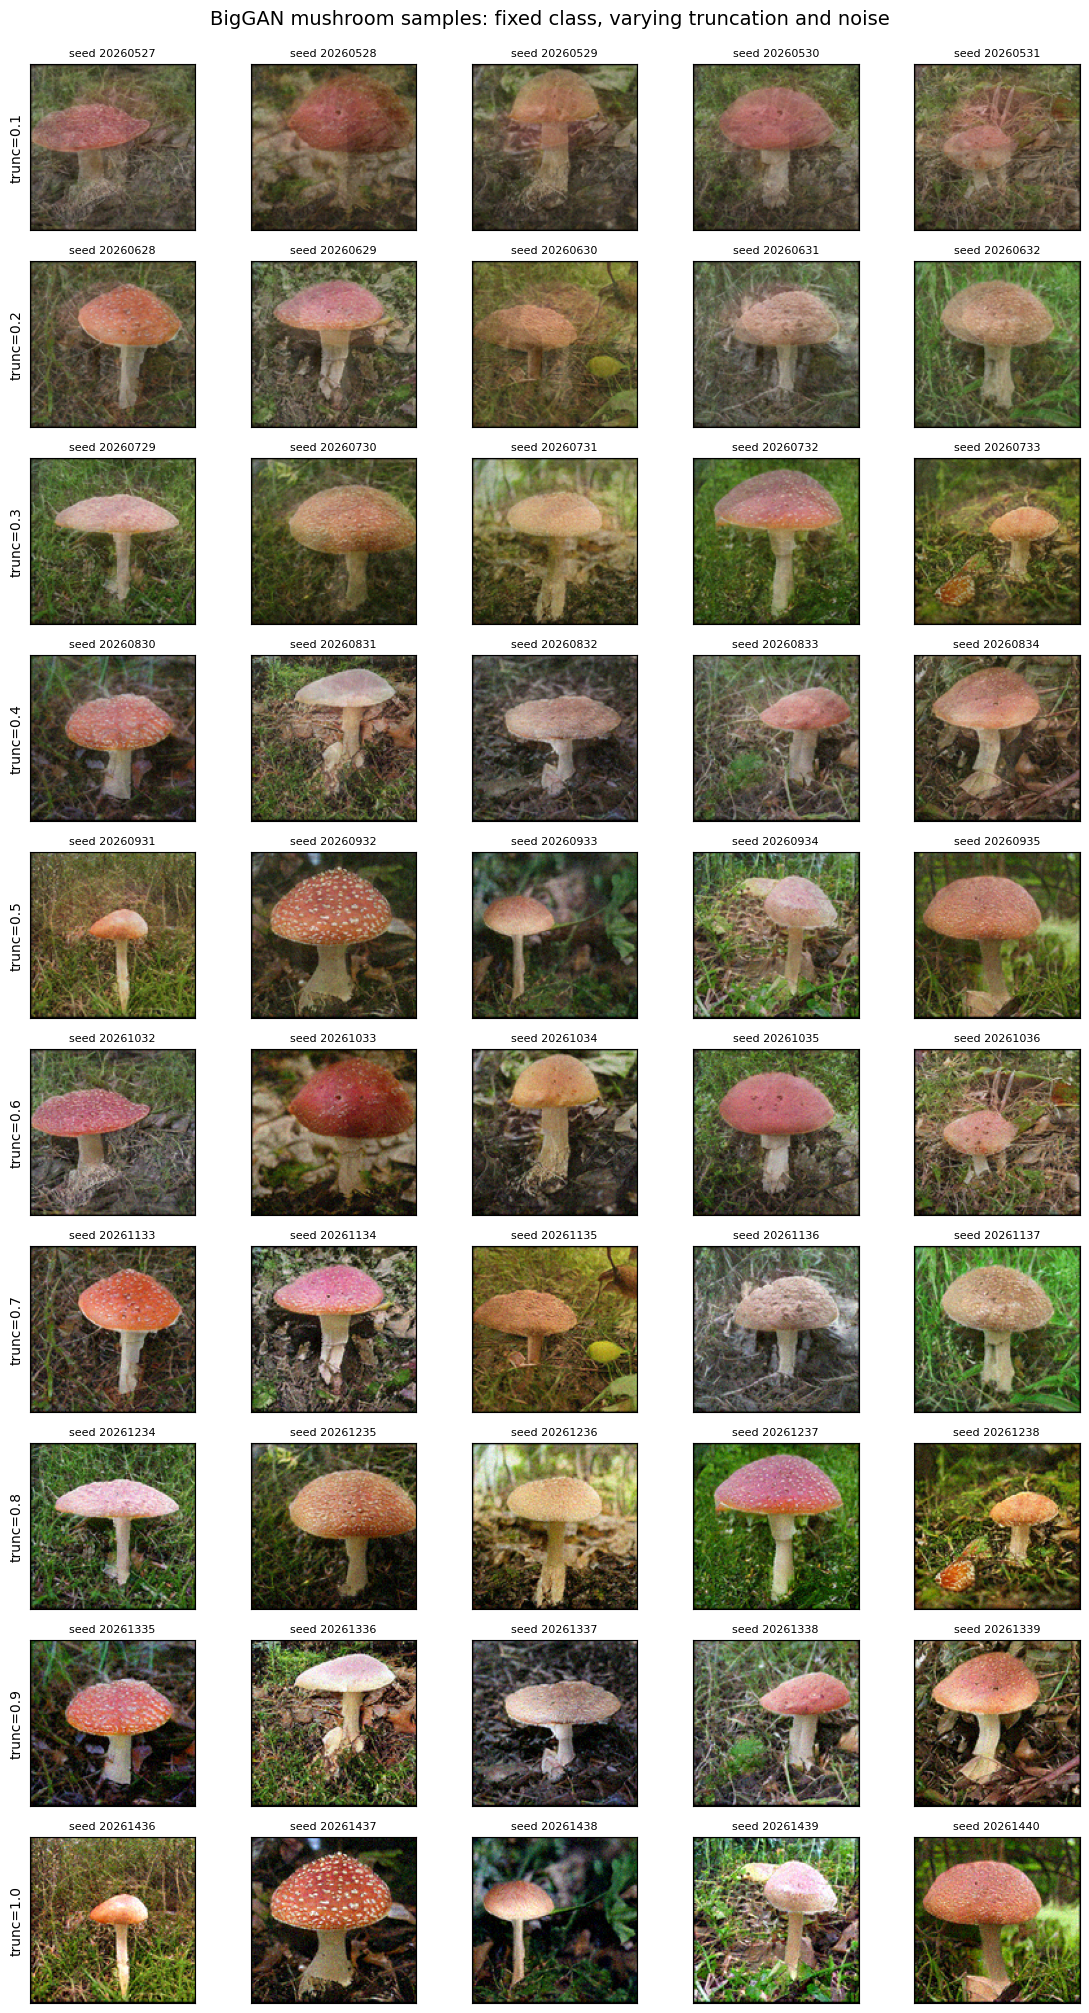

saved: /Users/junhaocheng/working-dir/研一下/深度学习/biggan_mushroom_grid.png


In [6]:
fig, axes = plt.subplots(
    factors_count,
    samples_per_factor,
    figsize=(2.3 * samples_per_factor, 2.05 * factors_count),
)

for row_idx, factor in enumerate(truncation_factors):
    for col_idx in range(samples_per_factor):
        ax = axes[row_idx, col_idx]
        image = images_by_factor[row_idx][col_idx]
        ax.imshow(image)
        ax.set_xticks([])
        ax.set_yticks([])
        seed = seed_log[row_idx]
        ax.set_title(f"seed {seed + col_idx}", fontsize=8)
        if col_idx == 0:
            ax.set_ylabel(f"trunc={factor:.1f}", fontsize=10)

fig.suptitle("BigGAN mushroom samples: fixed class, varying truncation and noise", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.savefig(grid_output_path, dpi=180)
plt.show()

print("saved:", Path(grid_output_path).resolve())

# Task 6 (14 marks)

In this task, you will add a simple quantitative check for visual diversity.

For each truncation factor, compute one diversity score using the 5 generated images in that row. A simple option is to calculate the average pixel-wise standard deviation across the 5 images. You may also use another reasonable simple metric, such as average pairwise mean squared error, as long as you explain it briefly.

Additional requirements:
1. Compute one diversity score for each truncation factor.
2. Store the scores in an array or list called `diversity_scores`.
3. Plot `diversity_scores` against `truncation_factors`.
4. Add a title and axis labels to the plot.

Useful functions for this task:
* `numpy.std`
* `numpy.mean`
* `matplotlib.pyplot.plot`
* `matplotlib.pyplot.xlabel`
* `matplotlib.pyplot.ylabel`

Expected length of `diversity_scores`: `10`

,truncation_factor,diversity_score
0,0.1,0.049001
1,0.2,0.059875
2,0.3,0.077314
3,0.4,0.088272
4,0.5,0.102876
5,0.6,0.115258
6,0.7,0.125589
7,0.8,0.149037
8,0.9,0.160688
9,1.0,0.175358


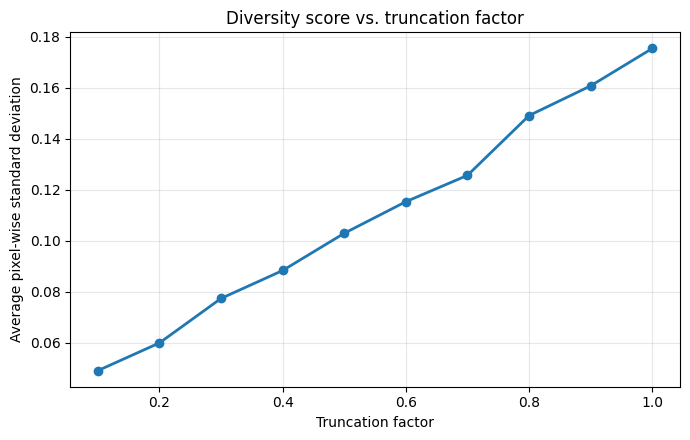

saved: /Users/junhaocheng/working-dir/研一下/深度学习/biggan_mushroom_diversity.png


In [7]:
diversity_scores = np.array([
    np.mean(np.std(row, axis=0))
    for row in images_by_factor
], dtype=np.float32)

diversity_df = pd.DataFrame({
    "truncation_factor": truncation_factors,
    "diversity_score": diversity_scores,
})
display(diversity_df)

plt.figure(figsize=(7, 4.5))
plt.plot(truncation_factors, diversity_scores, marker="o", linewidth=2)
plt.title("Diversity score vs. truncation factor")
plt.xlabel("Truncation factor")
plt.ylabel("Average pixel-wise standard deviation")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(diversity_output_path, dpi=180)
plt.show()

print("saved:", Path(diversity_output_path).resolve())

# Task 7 (14 marks)

Wow, so many mushrooms.

This has been an amazing adventure. Now make a conclusion based on both your image grid and your diversity-score plot.

Write a short answer of around **150-250 words**. Your answer should discuss the following questions:

1. What is the relationship between truncation and image diversity?
2. What is the relationship between truncation and image quality?
3. Did you see any extremely unusual samples in the generated images?
4. Why does truncation affect the batch in this way?
5. Does your diversity score support your visual observation? Why or why not?

If it is not clear what to make of the 50 images, re-run the procedure with a different set of random seeds and compare the new results with your first run.

**Answer:**

In this experiment, the diversity score increases as the truncation factor becomes larger. This agrees with the visual grid: the low-truncation rows look more conservative and share more similar color, pose, and background structure, while the high-truncation rows contain stronger differences in cap color, texture, lighting, and surrounding vegetation. In other words, truncation controls how far the sampled latent vectors move away from the model's high-density region. Smaller truncation keeps samples close to typical mushroom examples, which usually improves stability and perceived image quality but reduces diversity. Larger truncation allows the noise vectors to explore a wider part of the latent space, so the generated mushrooms become more varied.

The trade-off is that high truncation can also produce less regular details. In the grid, some high-truncation samples have stronger color shifts, noisy texture, or less natural contrast, although most images still look recognizably like mushrooms. The diversity metric supports the visual observation because it measures average pixel variation within each row: rows with more varied shapes, colors, and backgrounds receive larger scores. The metric is simple and does not understand semantic quality, but it is useful here because the class label is fixed and the main change is visual spread caused by truncation and noise.